# 03 — Phân tích tương quan giao thông sau TomTom → OSM map-matching

Notebook này hiện thực các phần:

- **3.1.** Mô tả dữ liệu và không gian nút sau map-matching  
- **3.2.** Phân tích đặc điểm tốc độ và ùn tắc theo thời gian  
- **3.3.** Xây dựng ma trận tương quan giao thông  
- **3.4.** Phân tích phân bố tương quan giữa các nút  
- **3.5.** Phân tích tương quan theo khoảng cách địa lý  
- **3.6.** Phân tích tương quan theo topology mạng đường OSM  
- **3.7.** Phân tích cụm/cộng đồng tương quan  
- **3.8.** Phân tích quan hệ tương quan có độ trễ  
- **3.9.** Phân tích độ ổn định của tương quan theo thời gian  
- **3.10.** Nhận xét và hàm ý cho bài toán dự đoán  

## Định nghĩa dùng trong đề tài

Vì TomTom cung cấp dữ liệu ở cấp **đoạn đường**, notebook này dùng định nghĩa:

> **Một node trong mô hình = một matched OSM directed edge có dữ liệu TomTom.**

Nói cách khác, phân tích ở đây là **tương quan đoạn đường – đoạn đường**.


## 0. Cấu hình đường dẫn

Đặt notebook vào:

```text
UTraffic-ML/ml_core/notebooks/03_analysis_osm_segment_correlation.ipynb
```

Yêu cầu đã chạy trước:

```text
ml_core/src/data_processing/run_osm_match_offline.py
```

Notebook sẽ đọc dữ liệu từ:

```text
ml_core/src/data_processing/outputs/branchA/
```


In [1]:

from __future__ import annotations

import json
import math
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import networkx as nx
except Exception as e:
    nx = None
    print("WARNING: networkx chưa sẵn sàng:", e)

# =============================================================================
# PATH AUTO-DETECT
# =============================================================================

def find_project_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "ml_core").exists() and (p / "dataset").exists():
            return p
        if p.name == "UTraffic-ML":
            return p
    # fallback nếu notebook nằm trong UTraffic-ML/ml_core/notebooks
    return start.resolve().parents[1]

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)
ML_CORE_ROOT = PROJECT_ROOT / "ml_core"
DATA_PROCESSING_DIR = ML_CORE_ROOT / "src" / "data_processing"

OUTPUT_BASE = DATA_PROCESSING_DIR / "outputs" / "branchA"
ANALYSIS_DIR = OUTPUT_BASE / "analysis_report"
PLOTS_DIR = ANALYSIS_DIR / "plots"
TABLES_DIR = ANALYSIS_DIR / "tables"
MATRICES_DIR = ANALYSIS_DIR / "matrices"

for d in [ANALYSIS_DIR, PLOTS_DIR, TABLES_DIR, MATRICES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("OUTPUT_BASE  :", OUTPUT_BASE)
print("ANALYSIS_DIR :", ANALYSIS_DIR)

assert OUTPUT_BASE.exists(), f"Không tìm thấy OUTPUT_BASE: {OUTPUT_BASE}. Hãy chạy run_osm_match_offline.py trước."


PROJECT_ROOT : C:\AI\Thesis\UTraffic-ML
OUTPUT_BASE  : C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA
ANALYSIS_DIR : C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report


In [2]:

# =============================================================================
# GLOBAL CONFIG
# =============================================================================

ANALYSIS_FEATURE = "average_speed"   # Có thể đổi: travel_time_ratio, congestion_index
MIN_VALID_RATIO = 0.80               # Giữ node có dữ liệu >= 80%
CORR_WINDOW = 10                     # w10

MAX_DIST_PAIRS = 1_500_000
MAX_HOP_SOURCES = 350
MAX_LAG_NODES = 1000
MAX_STABILITY_NODES = 800
STABILITY_STEP = 4
TOP_K_CORR_GRAPH = 10
CORR_GRAPH_THRESHOLD = 0.50

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("ANALYSIS_FEATURE:", ANALYSIS_FEATURE)
print("MIN_VALID_RATIO :", MIN_VALID_RATIO)
print("CORR_WINDOW     :", CORR_WINDOW)


ANALYSIS_FEATURE: average_speed
MIN_VALID_RATIO : 0.8
CORR_WINDOW     : 10


## 1. Hàm tiện ích

In [3]:

def latest_file(folder: Path, pattern: str) -> Path:
    files = sorted(folder.glob(pattern))
    if not files:
        raise FileNotFoundError(f"Không tìm thấy file {pattern} trong {folder}")
    return files[-1]


def load_json(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def save_json(obj: Dict[str, Any], path: Path) -> None:
    class NpEncoder(json.JSONEncoder):
        def default(self, o):
            if isinstance(o, np.integer):
                return int(o)
            if isinstance(o, np.floating):
                return float(o)
            if isinstance(o, np.ndarray):
                return o.tolist()
            return super().default(o)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, cls=NpEncoder)


def read_npz_columns(npz_path: Path, columns: Optional[List[str]] = None) -> pd.DataFrame:
    data = np.load(str(npz_path), allow_pickle=True)
    available = [k for k in data.files if k != "_metadata"]
    if columns is None:
        use_cols = available
    else:
        use_cols = [c for c in columns if c in available]
        missing = [c for c in columns if c not in available]
        if missing:
            print("WARNING missing columns:", missing)
    return pd.DataFrame({c: data[c] for c in use_cols})


def parse_time_minutes(x: Any) -> Optional[int]:
    import re
    if x is None:
        return None
    s = str(x)
    m = re.search(r"(?<!\d)([0-2]?\d):([0-5]\d)(?!\d)", s)
    if m:
        hh, mm = int(m.group(1)), int(m.group(2))
        if 0 <= hh <= 23:
            return hh * 60 + mm
    m = re.search(r"(?<!\d)([0-2]\d)([0-5]\d)(?!\d)", s)
    if m:
        hh, mm = int(m.group(1)), int(m.group(2))
        if 0 <= hh <= 23:
            return hh * 60 + mm
    return None


def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))


def standardize_matrix(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    X = X.astype(np.float32, copy=False)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd)
    Z = (X - mu) / sd
    return np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def sample_upper_triangle_values(R: np.ndarray, max_values: int = 2_000_000) -> np.ndarray:
    n = R.shape[0]
    total = n * (n - 1) // 2
    if total <= max_values:
        iu = np.triu_indices(n, k=1)
        return R[iu]
    vals = np.empty(max_values, dtype=np.float32)
    for k in range(max_values):
        i = np.random.randint(0, n - 1)
        j = np.random.randint(i + 1, n)
        vals[k] = R[i, j]
    return vals


def savefig(name: str, dpi: int = 160):
    path = PLOTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved plot:", path)
    plt.show()


## 2. Load dữ liệu đầu vào từ output Branch A

In [4]:

summary_path = OUTPUT_BASE / "match_summary" / "matching_summary.json"
edge_meta_path = OUTPUT_BASE / "match_summary" / "matched_osm_edge_metadata.csv"
match_table_path = OUTPUT_BASE / "match_summary" / "tomtom_to_osm_edge_matches.csv.gz"
traffic_npz_path = latest_file(OUTPUT_BASE / "traffic_features", "traffic_features_*.npz")
graph_npz_path = latest_file(OUTPUT_BASE / "graph_structure", "graph_structure_*.npz")
osm_npz_path = latest_file(OUTPUT_BASE / "osm_graph", "osm_graph_*.npz")

print("summary_path    :", summary_path)
print("edge_meta_path  :", edge_meta_path)
print("match_table_path:", match_table_path)
print("traffic_npz_path:", traffic_npz_path)
print("graph_npz_path  :", graph_npz_path)
print("osm_npz_path    :", osm_npz_path)

summary = load_json(summary_path)
edge_meta = pd.read_csv(edge_meta_path)
match_df = pd.read_csv(match_table_path, compression="gzip")

print("\nEdge metadata shape:", edge_meta.shape)
print("Match table shape  :", match_df.shape)
edge_meta.head()


summary_path    : C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\match_summary\matching_summary.json
edge_meta_path  : C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\match_summary\matched_osm_edge_metadata.csv
match_table_path: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\match_summary\tomtom_to_osm_edge_matches.csv.gz
traffic_npz_path: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\traffic_features\traffic_features_20260427_152139.npz
graph_npz_path  : C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\graph_structure\graph_structure_20260427_152321.npz
osm_npz_path    : C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\osm_graph\osm_graph_20260427_152259.npz

Edge metadata shape: (3697, 22)
Match table shape  : (16735, 25)


,model_node_id,osm_edge_id,osm_u_id,osm_v_id,osm_u_idx,osm_v_idx,u_lat,u_lon,v_lat,v_lon,...,osm_length_m,osm_maxspeed,osm_lanes,osm_highway_type,tomtom_unique_segments,tomtom_match_rows,mean_match_dist_m,median_match_dist_m,street_names,tomtom_segment_ids
0,0,411923503_5778872999,411923503,5778872999,393,1862,10.764715,106.694632,10.764953,106.694923,...,41.306496,50.0,2.0,5,10,10,6.749172,0.0,Đường Cô Bắc|Đường Đề Thám,-17040018735667|-17040018853961|-1704001899225...
1,1,411926179_411926209,411926179,411926209,554,562,10.762365,106.694036,10.763515,106.693169,...,159.094711,0.0,1.0,5,23,23,11.278386,0.0,Đường Cô Giang|Đường Đề Thám|Đường Nguyễn Khắc...,-17040018735852|-17040018853961|-1704001887346...
2,2,411926179_411922587,411926179,411922587,554,368,10.762365,106.694036,10.761072,106.692561,...,216.028961,50.0,2.0,5,23,23,9.917321,0.0,Đường Cô Giang|Đường Nguyễn Khắc Nhu|Đường Võ ...,-17040018735852|-17040018873461|-1704001927087...
3,3,411926179_5772158997,411926179,5772158997,554,1685,10.762365,106.694036,10.763723,106.695629,...,230.294418,50.0,2.0,5,24,24,27.084261,0.0,Đường Cô Giang|Đường Nguyễn Khắc Nhu|Đường Võ ...,-17040018735852|-17040018873461|-1704001927087...
4,4,411919179_6789193622,411919179,6789193622,243,2116,10.769420,106.699924,10.768644,106.700400,...,100.682457,0.0,2.0,4,5,5,2.658047,0.0,Đường Phó Đức Chính|Đường Nguyễn Thái Bình,-17040018760205|-17040018886720|-1704001892558...


In [5]:

needed_cols = [
    "segment_id",
    "date_from",
    "date_range",
    "time_set",
    "average_speed",
    "harmonic_average_speed",
    "median_speed",
    "std_speed",
    "average_travel_time",
    "travel_time_ratio",
    "congestion_index",
    "speed_limit_ratio",
    "sample_size",
]

traffic_df = read_npz_columns(traffic_npz_path, needed_cols)
traffic_df["segment_id"] = traffic_df["segment_id"].astype(str)
traffic_df["time_set"] = traffic_df["time_set"].astype(str)

date_col = "date_from" if "date_from" in traffic_df.columns else "date_range"
traffic_df[date_col] = traffic_df[date_col].astype(str)

for c in needed_cols:
    if c in traffic_df.columns and c not in ["segment_id", "date_from", "date_range", "time_set"]:
        traffic_df[c] = pd.to_numeric(traffic_df[c], errors="coerce")

print("Traffic df shape:", traffic_df.shape)
print("Unique TomTom segments:", traffic_df["segment_id"].nunique())
print("Unique dates:", traffic_df[date_col].nunique())
print("Unique time slots:", traffic_df["time_set"].nunique())
traffic_df.head()


Traffic df shape: (5006160, 13)
Unique TomTom segments: 6953
Unique dates: 30
Unique time slots: 24


,segment_id,date_from,date_range,time_set,average_speed,harmonic_average_speed,median_speed,std_speed,average_travel_time,travel_time_ratio,congestion_index,speed_limit_ratio,sample_size
0,-17040018834260,2024-08-01,2024-08-01,Slot_0600,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,0.0
1,-17040018834260,2024-08-01,2024-08-01,Slot_0615,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,0.0
2,-17040018834260,2024-08-01,2024-08-01,Slot_0630,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,0.0
3,-17040018834260,2024-08-01,2024-08-01,Slot_0645,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,0.0
4,-17040018834260,2024-08-01,2024-08-01,Slot_0700,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,0.0


## 3.1. Mô tả dữ liệu và không gian nút sau map-matching

In [6]:

print("===== MATCHING SUMMARY =====")
print(json.dumps(summary.get("match", {}), ensure_ascii=False, indent=2))

basic_summary = {
    "num_job_files": summary.get("num_job_files"),
    "records_kept": summary.get("records_kept"),
    "unique_tomtom_segments": summary.get("unique_tomtom_segments"),
    "unique_dates": summary.get("unique_dates"),
    "unique_time_slots": summary.get("unique_time_slots"),
    "matched_tomtom_segments": summary.get("match", {}).get("matched_tomtom_segments"),
    "coverage_tomtom_segments": summary.get("match", {}).get("coverage_tomtom_segments"),
    "matched_osm_directed_edges": summary.get("match", {}).get("matched_osm_directed_edges"),
    "matched_osm_undirected_edges": summary.get("match", {}).get("matched_osm_undirected_edges"),
    "model_nodes_for_branchA_B": summary.get("match", {}).get("model_nodes_for_branchA_B"),
}

basic_summary_df = pd.DataFrame(list(basic_summary.items()), columns=["metric", "value"])
basic_summary_df.to_csv(TABLES_DIR / "3_1_basic_matching_summary.csv", index=False, encoding="utf-8-sig")
basic_summary_df


===== MATCHING SUMMARY =====
{
  "match_threshold_m": 50.0,
  "total_tomtom_segments": 6953,
  "matched_tomtom_segments": 6934,
  "coverage_tomtom_segments": 0.9972673666043435,
  "matched_osm_directed_edges": 3697,
  "matched_osm_undirected_edges": 2703,
  "model_node_definition": "matched_osm_directed_edge",
  "model_nodes_for_branchA_B": 3697
}


,metric,value
0,num_job_files,3.000000e+01
1,records_kept,5.006160e+06
2,unique_tomtom_segments,6.953000e+03
3,unique_dates,3.000000e+01
4,unique_time_slots,2.400000e+01
5,matched_tomtom_segments,6.934000e+03
6,coverage_tomtom_segments,9.972674e-01
7,matched_osm_directed_edges,3.697000e+03
8,matched_osm_undirected_edges,2.703000e+03
9,model_nodes_for_branchA_B,3.697000e+03


In [7]:

cols_for_desc = [
    "osm_length_m",
    "tomtom_unique_segments",
    "tomtom_match_rows",
    "mean_match_dist_m",
    "median_match_dist_m",
]
desc = edge_meta[[c for c in cols_for_desc if c in edge_meta.columns]].describe().T
desc.to_csv(TABLES_DIR / "3_1_edge_metadata_describe.csv", encoding="utf-8-sig")
desc


,count,mean,std,min,25%,50%,75%,max
osm_length_m,3697.0,86.054322,82.638378,1.065328,29.790752,63.350414,121.400406,934.885925
tomtom_unique_segments,3697.0,4.525020,4.217758,1.000000,2.000000,3.000000,6.000000,42.000000
tomtom_match_rows,3697.0,4.526643,4.218967,1.000000,2.000000,3.000000,6.000000,42.000000
mean_match_dist_m,3697.0,63.688023,97.452041,0.000000,3.192886,27.963165,84.479486,851.829481
median_match_dist_m,3697.0,54.505904,102.922709,0.000000,0.000000,6.774418,67.558029,851.829481


Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_1_osm_edge_length_distribution.png


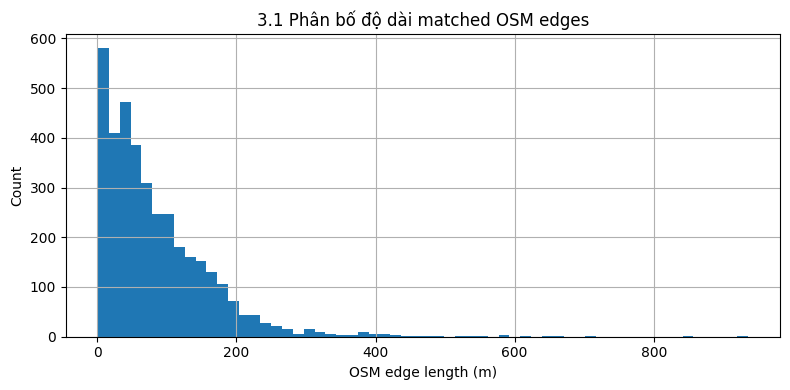

Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_1_tomtom_segments_per_osm_edge.png


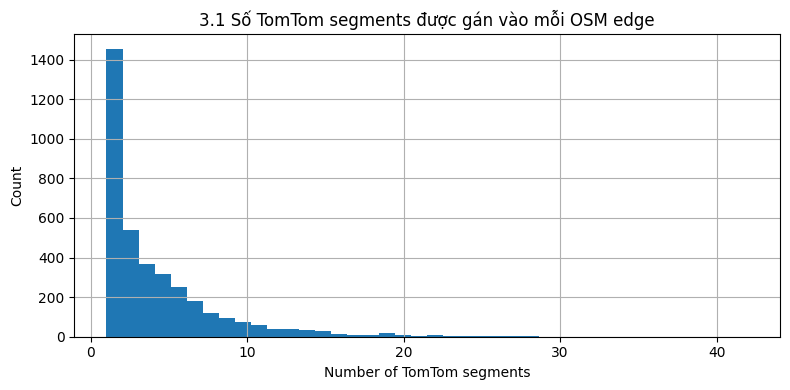

Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_1_match_distance_distribution.png


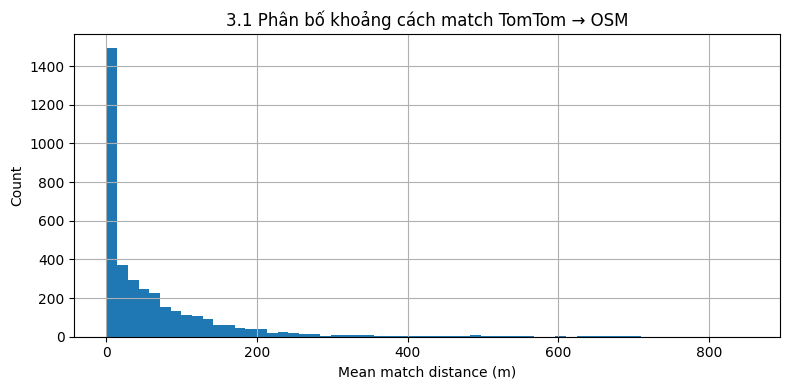

In [8]:

plt.figure(figsize=(8, 4))
edge_meta["osm_length_m"].dropna().hist(bins=60)
plt.title("3.1 Phân bố độ dài matched OSM edges")
plt.xlabel("OSM edge length (m)")
plt.ylabel("Count")
savefig("3_1_osm_edge_length_distribution.png")

plt.figure(figsize=(8, 4))
edge_meta["tomtom_unique_segments"].dropna().hist(bins=40)
plt.title("3.1 Số TomTom segments được gán vào mỗi OSM edge")
plt.xlabel("Number of TomTom segments")
plt.ylabel("Count")
savefig("3_1_tomtom_segments_per_osm_edge.png")

if "mean_match_dist_m" in edge_meta.columns:
    plt.figure(figsize=(8, 4))
    edge_meta["mean_match_dist_m"].dropna().hist(bins=60)
    plt.title("3.1 Phân bố khoảng cách match TomTom → OSM")
    plt.xlabel("Mean match distance (m)")
    plt.ylabel("Count")
    savefig("3_1_match_distance_distribution.png")


## 3.2. Phân tích đặc điểm tốc độ và ùn tắc theo thời gian

Bước này aggregate dữ liệu động từ TomTom segment sang **matched OSM edge**.

- Với tốc độ/travel time/congestion: lấy **mean** nếu nhiều TomTom segment rơi vào cùng OSM edge.
- Với `sample_size`: lấy **sum**.


In [9]:

traffic_df["_time_minutes"] = traffic_df["time_set"].apply(parse_time_minutes)
traffic_df["_date_parsed"] = pd.to_datetime(traffic_df[date_col], errors="coerce")
traffic_df["_date_key"] = traffic_df["_date_parsed"].dt.strftime("%Y-%m-%d")
traffic_df["_date_key"] = traffic_df["_date_key"].fillna(traffic_df[date_col].astype(str))

if traffic_df["_time_minutes"].isna().any():
    time_order = {v: i for i, v in enumerate(sorted(traffic_df["time_set"].unique()))}
    fallback_minutes = traffic_df["time_set"].map(time_order).astype(float)
    traffic_df["_time_minutes"] = traffic_df["_time_minutes"].fillna(fallback_minutes)

traffic_df["_timestamp_key"] = traffic_df["_date_key"].astype(str) + "__" + traffic_df["time_set"].astype(str)

timestamp_table = (
    traffic_df[["_timestamp_key", "_date_key", "time_set", "_time_minutes"]]
    .drop_duplicates()
    .sort_values(["_date_key", "_time_minutes", "time_set"])
    .reset_index(drop=True)
)
timestamp_table["timestamp_idx"] = np.arange(len(timestamp_table), dtype=np.int64)
timestamp_table.to_csv(TABLES_DIR / "timestamp_table.csv", index=False, encoding="utf-8-sig")

traffic_df = traffic_df.merge(timestamp_table[["_timestamp_key", "timestamp_idx"]], on="_timestamp_key", how="left")

print("Number of timestamps:", len(timestamp_table))
timestamp_table.head()


Number of timestamps: 720


,_timestamp_key,_date_key,time_set,_time_minutes,timestamp_idx
0,2024-08-01__Slot_0600,2024-08-01,Slot_0600,360,0
1,2024-08-01__Slot_0615,2024-08-01,Slot_0615,375,1
2,2024-08-01__Slot_0630,2024-08-01,Slot_0630,390,2
3,2024-08-01__Slot_0645,2024-08-01,Slot_0645,405,3
4,2024-08-01__Slot_0700,2024-08-01,Slot_0700,420,4


In [10]:

match_df["segment_id"] = match_df["segment_id"].astype(str)

for c in ["osm_u_idx", "osm_v_idx"]:
    match_df[c] = pd.to_numeric(match_df[c], errors="coerce").astype("Int64")
    edge_meta[c] = pd.to_numeric(edge_meta[c], errors="coerce").astype("Int64")

mapping_df = (
    match_df[["segment_id", "osm_u_idx", "osm_v_idx"]]
    .dropna()
    .drop_duplicates()
    .merge(
        edge_meta[["model_node_id", "osm_edge_id", "osm_u_idx", "osm_v_idx"]],
        on=["osm_u_idx", "osm_v_idx"],
        how="inner",
    )
    .drop_duplicates(subset=["segment_id", "model_node_id"])
)

mapping_df["model_node_id"] = mapping_df["model_node_id"].astype(np.int64)

print("Mapping rows:", len(mapping_df))
print("Unique TomTom segments in mapping:", mapping_df["segment_id"].nunique())
print("Unique model nodes in mapping:", mapping_df["model_node_id"].nunique())

mapping_df.to_csv(TABLES_DIR / "segment_to_model_node_mapping.csv", index=False, encoding="utf-8-sig")
mapping_df.head()


Mapping rows: 16729
Unique TomTom segments in mapping: 6934
Unique model nodes in mapping: 3697


,segment_id,osm_u_idx,osm_v_idx,model_node_id,osm_edge_id
0,-17040018735667,393,1862,0,411923503_5778872999
1,-17040018735852,554,562,1,411926179_411926209
2,-17040018735852,554,368,2,411926179_411922587
3,-17040018735852,554,1685,3,411926179_5772158997
4,-17040018760205,243,2116,4,411919179_6789193622


In [11]:

dynamic_cols = [
    c for c in [
        "average_speed",
        "harmonic_average_speed",
        "median_speed",
        "std_speed",
        "average_travel_time",
        "travel_time_ratio",
        "congestion_index",
        "speed_limit_ratio",
        "sample_size",
    ]
    if c in traffic_df.columns
]

traffic_small = traffic_df[["segment_id", "timestamp_idx", "_date_key", "time_set", "_time_minutes"] + dynamic_cols].copy()

print("Merging traffic records with segment->OSM-edge mapping...")
merged = traffic_small.merge(
    mapping_df[["segment_id", "model_node_id"]],
    on="segment_id",
    how="inner",
)
print("Merged shape:", merged.shape)

agg_dict = {}
for c in dynamic_cols:
    agg_dict[c] = "sum" if c == "sample_size" else "mean"

osm_ts = (
    merged
    .groupby(["timestamp_idx", "model_node_id"], as_index=False)
    .agg(agg_dict)
)

print("OSM edge time series rows:", len(osm_ts))
print("Unique model nodes:", osm_ts["model_node_id"].nunique())
print("Unique timestamps:", osm_ts["timestamp_idx"].nunique())

try:
    ts_path = ANALYSIS_DIR / "osm_edge_timeseries.parquet"
    osm_ts.to_parquet(ts_path, index=False)
except Exception:
    ts_path = ANALYSIS_DIR / "osm_edge_timeseries.csv.gz"
    osm_ts.to_csv(ts_path, index=False, compression="gzip")

print("Saved OSM edge time series:", ts_path)
osm_ts.head()


Merging traffic records with segment->OSM-edge mapping...
Merged shape: (12044880, 15)
OSM edge time series rows: 2661840
Unique model nodes: 3697
Unique timestamps: 720
Saved OSM edge time series: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\osm_edge_timeseries.parquet


,timestamp_idx,model_node_id,average_speed,harmonic_average_speed,median_speed,std_speed,average_travel_time,travel_time_ratio,congestion_index,speed_limit_ratio,sample_size
0,0,0,6.000000,2.570000,6.500000,10.075000,6.418000,0.400000,0.800000,0.200000,19.0
1,0,1,13.147826,12.830435,12.173913,3.083333,2.316522,0.521739,0.586029,0.413971,30.0
2,0,2,13.952174,13.586957,12.956522,3.500000,2.153043,0.521739,0.582696,0.417304,39.0
3,0,3,15.158333,14.570833,14.250000,4.315385,6.820833,0.541667,0.575917,0.424083,135.0
4,0,4,19.000000,16.260000,17.660000,5.775000,10.174000,0.800000,0.553600,0.446400,14.0


In [12]:

network_time = (
    osm_ts
    .merge(timestamp_table, on="timestamp_idx", how="left")
    .groupby(["timestamp_idx", "_date_key", "time_set", "_time_minutes"], as_index=False)
    .agg({
        "average_speed": "mean" if "average_speed" in osm_ts.columns else "first",
        "travel_time_ratio": "mean" if "travel_time_ratio" in osm_ts.columns else "first",
        "congestion_index": "mean" if "congestion_index" in osm_ts.columns else "first",
        "sample_size": "sum" if "sample_size" in osm_ts.columns else "first",
    })
)

network_time.to_csv(TABLES_DIR / "3_2_network_time_summary.csv", index=False, encoding="utf-8-sig")
network_time.head()


,timestamp_idx,_date_key,time_set,_time_minutes,average_speed,travel_time_ratio,congestion_index,sample_size
0,0,2024-08-01,Slot_0600,360,23.108186,0.788707,0.489484,216379.0
1,1,2024-08-01,Slot_0615,375,22.688980,0.862934,0.495555,271420.0
2,2,2024-08-01,Slot_0630,390,22.373035,0.856438,0.498465,320175.0
3,3,2024-08-01,Slot_0645,405,22.197637,0.889593,0.499642,372367.0
4,4,2024-08-01,Slot_0700,420,22.123370,0.932581,0.499417,430755.0


Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_2_network_average_speed_over_time.png


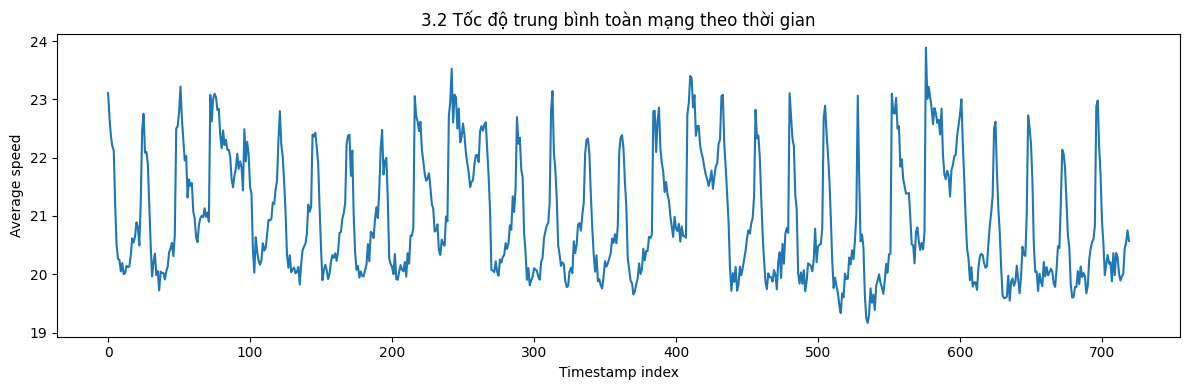

Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_2_network_congestion_over_time.png


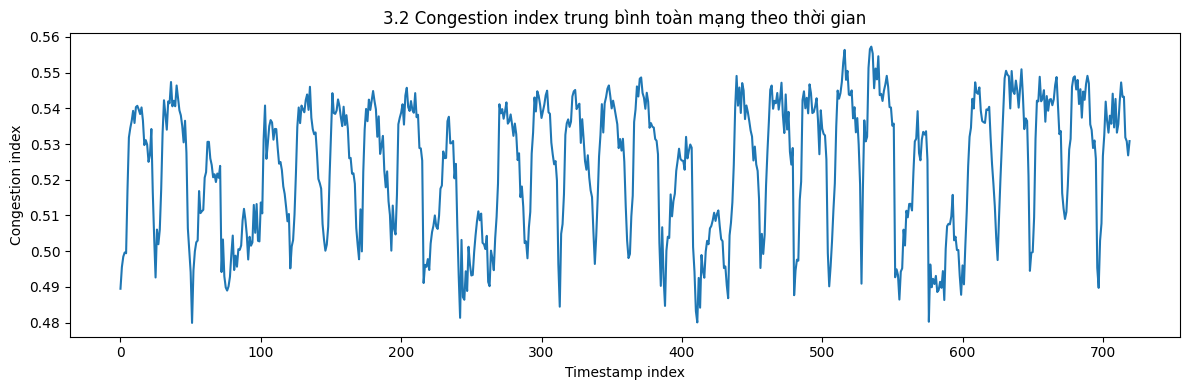

In [13]:

if "average_speed" in network_time.columns:
    plt.figure(figsize=(12, 4))
    plt.plot(network_time["timestamp_idx"], network_time["average_speed"])
    plt.title("3.2 Tốc độ trung bình toàn mạng theo thời gian")
    plt.xlabel("Timestamp index")
    plt.ylabel("Average speed")
    savefig("3_2_network_average_speed_over_time.png")

if "congestion_index" in network_time.columns:
    plt.figure(figsize=(12, 4))
    plt.plot(network_time["timestamp_idx"], network_time["congestion_index"])
    plt.title("3.2 Congestion index trung bình toàn mạng theo thời gian")
    plt.xlabel("Timestamp index")
    plt.ylabel("Congestion index")
    savefig("3_2_network_congestion_over_time.png")


Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_2_speed_boxplot_by_time_slot.png


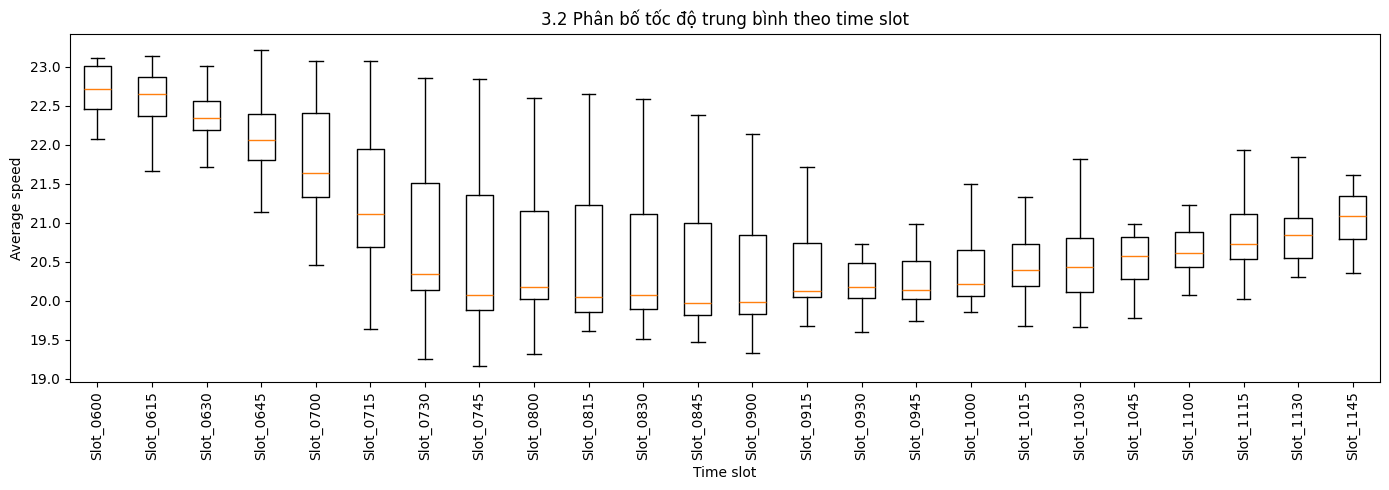

In [14]:

if "average_speed" in network_time.columns:
    by_slot = [g["average_speed"].dropna().values for _, g in network_time.groupby("time_set", sort=False)]
    labels = [str(k) for k, _ in network_time.groupby("time_set", sort=False)]

    plt.figure(figsize=(14, 5))
    plt.boxplot(by_slot, labels=labels, showfliers=False)
    plt.title("3.2 Phân bố tốc độ trung bình theo time slot")
    plt.xlabel("Time slot")
    plt.ylabel("Average speed")
    plt.xticks(rotation=90)
    savefig("3_2_speed_boxplot_by_time_slot.png")


Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_2_speed_heatmap_day_timeslot.png


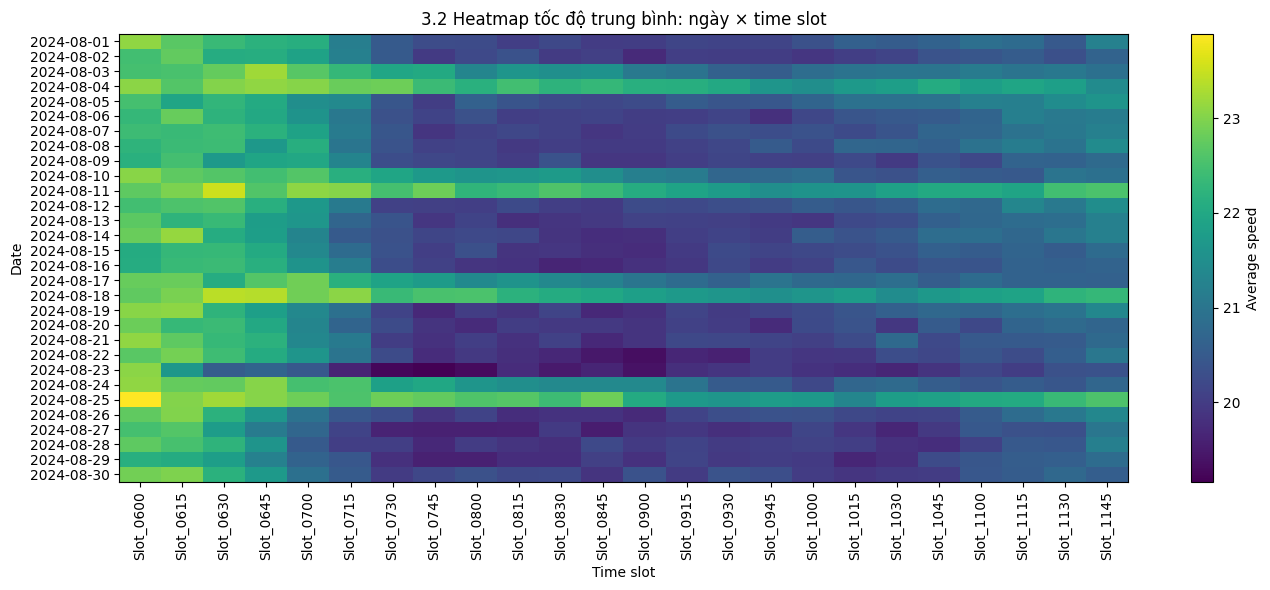

In [15]:

if "average_speed" in network_time.columns:
    heat = network_time.pivot_table(
        index="_date_key",
        columns="time_set",
        values="average_speed",
        aggfunc="mean",
    )
    plt.figure(figsize=(14, 6))
    plt.imshow(heat.values, aspect="auto")
    plt.title("3.2 Heatmap tốc độ trung bình: ngày × time slot")
    plt.xlabel("Time slot")
    plt.ylabel("Date")
    plt.xticks(np.arange(len(heat.columns)), heat.columns, rotation=90)
    plt.yticks(np.arange(len(heat.index)), heat.index)
    plt.colorbar(label="Average speed")
    savefig("3_2_speed_heatmap_day_timeslot.png")


## 3.3. Xây dựng ma trận tương quan giao thông

Ta xây ma trận:

\[
R_{ij} = Corr(X_i, X_j)
\]

với \(X_i\) là chuỗi tốc độ của matched OSM edge \(i\).


In [16]:

all_nodes = np.sort(edge_meta["model_node_id"].unique())
pivot = (
    osm_ts
    .pivot_table(index="timestamp_idx", columns="model_node_id", values=ANALYSIS_FEATURE, aggfunc="mean")
    .reindex(index=np.arange(len(timestamp_table)), columns=all_nodes)
)

valid_ratio = pivot.notna().mean(axis=0)
node_stats = pd.DataFrame({
    "model_node_id": valid_ratio.index.astype(int),
    "valid_ratio": valid_ratio.values,
    "missing_ratio": 1.0 - valid_ratio.values,
})
node_stats = node_stats.merge(edge_meta, on="model_node_id", how="left")
node_stats.to_csv(TABLES_DIR / "3_3_node_valid_ratio.csv", index=False, encoding="utf-8-sig")

selected_nodes = node_stats.loc[node_stats["valid_ratio"] >= MIN_VALID_RATIO, "model_node_id"].to_numpy(dtype=np.int64)
print("Total model nodes:", len(all_nodes))
print("Selected nodes for correlation:", len(selected_nodes))

X_df = pivot[selected_nodes].copy()
X_df = X_df.interpolate(limit_direction="both").ffill().bfill()
X_df = X_df.fillna(X_df.mean(axis=0)).fillna(0.0)

X = X_df.to_numpy(dtype=np.float32)
print("X shape [T, N]:", X.shape)

np.save(MATRICES_DIR / f"X_{ANALYSIS_FEATURE}_T_by_N.npy", X)
np.save(MATRICES_DIR / "selected_model_nodes.npy", selected_nodes)

node_stats.head()


Total model nodes: 3697
Selected nodes for correlation: 3697
X shape [T, N]: (720, 3697)


,model_node_id,valid_ratio,missing_ratio,osm_edge_id,osm_u_id,osm_v_id,osm_u_idx,osm_v_idx,u_lat,u_lon,...,osm_length_m,osm_maxspeed,osm_lanes,osm_highway_type,tomtom_unique_segments,tomtom_match_rows,mean_match_dist_m,median_match_dist_m,street_names,tomtom_segment_ids
0,0,1.0,0.0,411923503_5778872999,411923503,5778872999,393,1862,10.764715,106.694632,...,41.306496,50.0,2.0,5,10,10,6.749172,0.0,Đường Cô Bắc|Đường Đề Thám,-17040018735667|-17040018853961|-1704001899225...
1,1,1.0,0.0,411926179_411926209,411926179,411926209,554,562,10.762365,106.694036,...,159.094711,0.0,1.0,5,23,23,11.278386,0.0,Đường Cô Giang|Đường Đề Thám|Đường Nguyễn Khắc...,-17040018735852|-17040018853961|-1704001887346...
2,2,1.0,0.0,411926179_411922587,411926179,411922587,554,368,10.762365,106.694036,...,216.028961,50.0,2.0,5,23,23,9.917321,0.0,Đường Cô Giang|Đường Nguyễn Khắc Nhu|Đường Võ ...,-17040018735852|-17040018873461|-1704001927087...
3,3,1.0,0.0,411926179_5772158997,411926179,5772158997,554,1685,10.762365,106.694036,...,230.294418,50.0,2.0,5,24,24,27.084261,0.0,Đường Cô Giang|Đường Nguyễn Khắc Nhu|Đường Võ ...,-17040018735852|-17040018873461|-1704001927087...
4,4,1.0,0.0,411919179_6789193622,411919179,6789193622,243,2116,10.769420,106.699924,...,100.682457,0.0,2.0,4,5,5,2.658047,0.0,Đường Phó Đức Chính|Đường Nguyễn Thái Bình,-17040018760205|-17040018886720|-1704001892558...


In [17]:

print("Computing full correlation matrix...")
R = np.corrcoef(X, rowvar=False).astype(np.float32)
R = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0)
np.fill_diagonal(R, 1.0)

print("R shape:", R.shape)
print("R min/max:", float(R.min()), float(R.max()))

np.save(MATRICES_DIR / f"R_full_{ANALYSIS_FEATURE}.npy", R)

corr_summary = {
    "analysis_feature": ANALYSIS_FEATURE,
    "num_timestamps": int(X.shape[0]),
    "num_nodes_total": int(len(all_nodes)),
    "num_nodes_selected": int(len(selected_nodes)),
    "min_valid_ratio": float(MIN_VALID_RATIO),
    "corr_min": float(R.min()),
    "corr_max": float(R.max()),
}
save_json(corr_summary, TABLES_DIR / "3_3_correlation_matrix_summary.json")
corr_summary


Computing full correlation matrix...
R shape: (3697, 3697)
R min/max: -0.5633754730224609 1.0


{'analysis_feature': 'average_speed',
 'num_timestamps': 720,
 'num_nodes_total': 3697,
 'num_nodes_selected': 3697,
 'min_valid_ratio': 0.8,
 'corr_min': -0.5633754730224609,
 'corr_max': 1.0}

Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_3_correlation_heatmap_sample.png


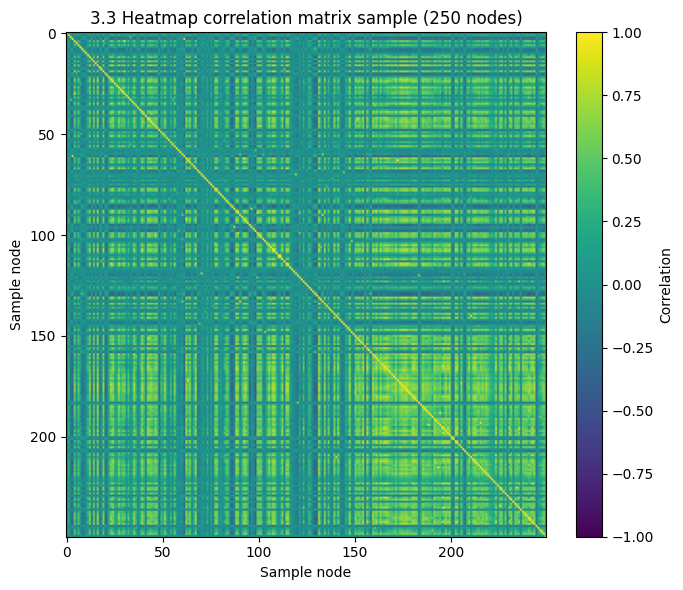

In [18]:

sample_n = min(250, R.shape[0])
sample_idx = np.linspace(0, R.shape[0] - 1, sample_n).astype(int)

plt.figure(figsize=(7, 6))
plt.imshow(R[np.ix_(sample_idx, sample_idx)], vmin=-1, vmax=1, aspect="auto")
plt.title(f"3.3 Heatmap correlation matrix sample ({sample_n} nodes)")
plt.xlabel("Sample node")
plt.ylabel("Sample node")
plt.colorbar(label="Correlation")
savefig("3_3_correlation_heatmap_sample.png")


## 3.4. Phân tích phân bố tương quan giữa các nút

In [19]:

corr_vals = sample_upper_triangle_values(R, max_values=2_000_000)
corr_vals = corr_vals[np.isfinite(corr_vals)]

corr_dist_summary = pd.DataFrame({
    "metric": [
        "count_sampled_pairs",
        "mean_corr",
        "std_corr",
        "mean_abs_corr",
        "q01",
        "q05",
        "q25",
        "q50",
        "q75",
        "q95",
        "q99",
        "ratio_corr_gt_0_3",
        "ratio_corr_gt_0_5",
        "ratio_corr_gt_0_7",
        "ratio_abs_corr_gt_0_5",
    ],
    "value": [
        len(corr_vals),
        float(np.mean(corr_vals)),
        float(np.std(corr_vals)),
        float(np.mean(np.abs(corr_vals))),
        float(np.quantile(corr_vals, 0.01)),
        float(np.quantile(corr_vals, 0.05)),
        float(np.quantile(corr_vals, 0.25)),
        float(np.quantile(corr_vals, 0.50)),
        float(np.quantile(corr_vals, 0.75)),
        float(np.quantile(corr_vals, 0.95)),
        float(np.quantile(corr_vals, 0.99)),
        float(np.mean(corr_vals > 0.3)),
        float(np.mean(corr_vals > 0.5)),
        float(np.mean(corr_vals > 0.7)),
        float(np.mean(np.abs(corr_vals) > 0.5)),
    ]
})
corr_dist_summary.to_csv(TABLES_DIR / "3_4_correlation_distribution_summary.csv", index=False, encoding="utf-8-sig")
corr_dist_summary


,metric,value
0,count_sampled_pairs,2.000000e+06
1,mean_corr,1.606109e-01
2,std_corr,2.808397e-01
3,mean_abs_corr,2.460713e-01
4,q01,-3.515526e-01
5,q05,-2.368960e-01
6,q25,-4.987302e-02
7,q50,9.049021e-02
8,q75,3.935582e-01
9,q95,6.457196e-01


Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_4_correlation_distribution.png


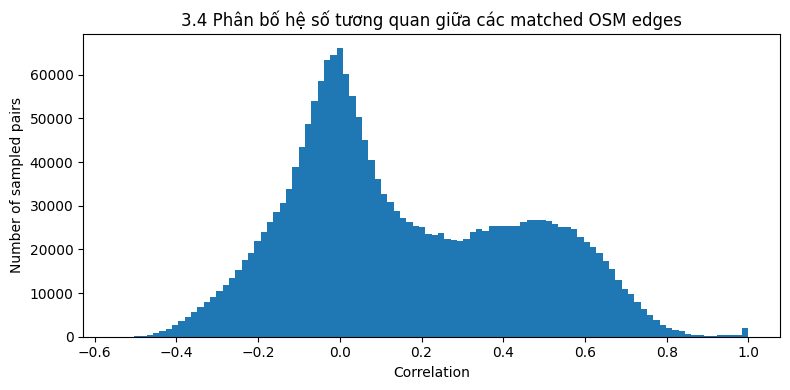

Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_4_abs_correlation_distribution.png


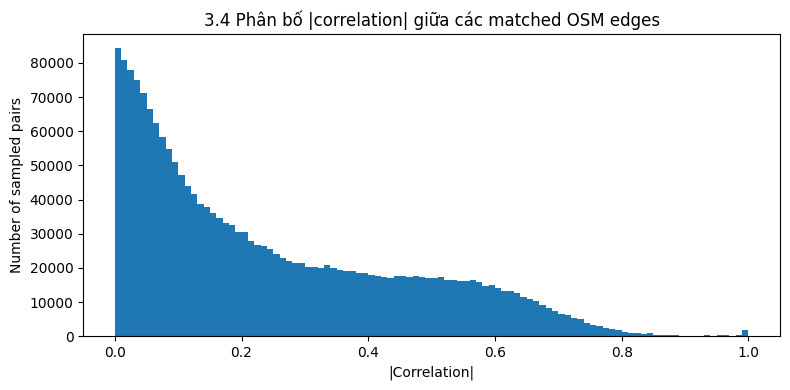

In [20]:

plt.figure(figsize=(8, 4))
plt.hist(corr_vals, bins=100)
plt.title("3.4 Phân bố hệ số tương quan giữa các matched OSM edges")
plt.xlabel("Correlation")
plt.ylabel("Number of sampled pairs")
savefig("3_4_correlation_distribution.png")

plt.figure(figsize=(8, 4))
plt.hist(np.abs(corr_vals), bins=100)
plt.title("3.4 Phân bố |correlation| giữa các matched OSM edges")
plt.xlabel("|Correlation|")
plt.ylabel("Number of sampled pairs")
savefig("3_4_abs_correlation_distribution.png")


In [21]:

def build_pair_table(R: np.ndarray, selected_nodes: np.ndarray, edge_meta: pd.DataFrame, top_k: int = 30):
    n = R.shape[0]
    R_work = R.copy()
    np.fill_diagonal(R_work, np.nan)
    flat = R_work.ravel()
    valid = np.isfinite(flat)

    pos_idx = np.argpartition(np.where(valid, flat, -np.inf), -top_k)[-top_k:]
    neg_idx = np.argpartition(np.where(valid, flat, np.inf), top_k)[:top_k]

    meta_small = edge_meta.set_index("model_node_id")

    def rows_from_flat(indices, label):
        rows = []
        for idx in indices:
            i = idx // n
            j = idx % n
            ni = int(selected_nodes[i])
            nj = int(selected_nodes[j])
            mi = meta_small.loc[ni] if ni in meta_small.index else {}
            mj = meta_small.loc[nj] if nj in meta_small.index else {}
            rows.append({
                "type": label,
                "node_i": ni,
                "node_j": nj,
                "corr": float(R[i, j]),
                "edge_i": mi.get("osm_edge_id", ""),
                "edge_j": mj.get("osm_edge_id", ""),
                "street_i": mi.get("street_names", ""),
                "street_j": mj.get("street_names", ""),
            })
        return rows

    rows = rows_from_flat(pos_idx, "top_positive") + rows_from_flat(neg_idx, "top_negative")
    return pd.DataFrame(rows).sort_values(["type", "corr"], ascending=[True, False])

top_pairs = build_pair_table(R, selected_nodes, edge_meta, top_k=30)
top_pairs.to_csv(TABLES_DIR / "3_4_top_positive_negative_pairs.csv", index=False, encoding="utf-8-sig")
top_pairs.head(10)


,type,node_i,node_j,corr,edge_i,edge_j,street_i,street_j
58,top_negative,1026,239,-0.537993,411925400_411920048,5778245684_411919210,Đường Trần Quý Khoách|Đường Trần Khánh Dư|Hẻm ...,Đường 3 Tháng 2|Công Trường Dân Chủ
59,top_negative,239,1026,-0.537993,5778245684_411919210,411925400_411920048,Đường 3 Tháng 2|Công Trường Dân Chủ,Đường Trần Quý Khoách|Đường Trần Khánh Dư|Hẻm ...
56,top_negative,2543,1026,-0.538006,2690659691_411921991,411925400_411920048,Đường 3 Tháng 2|Đường Cách Mạng Tháng 8,Đường Trần Quý Khoách|Đường Trần Khánh Dư|Hẻm ...
57,top_negative,1026,2543,-0.538006,411925400_411920048,2690659691_411921991,Đường Trần Quý Khoách|Đường Trần Khánh Dư|Hẻm ...,Đường 3 Tháng 2|Đường Cách Mạng Tháng 8
54,top_negative,1026,1763,-0.538382,411925400_411920048,10046800715_13623759833,Đường Trần Quý Khoách|Đường Trần Khánh Dư|Hẻm ...,Đường Cách Mạng Tháng 8
55,top_negative,1763,1026,-0.538382,10046800715_13623759833,411925400_411920048,Đường Cách Mạng Tháng 8,Đường Trần Quý Khoách|Đường Trần Khánh Dư|Hẻm ...
52,top_negative,292,1026,-0.539865,411921991_2690659691,411925400_411920048,Đường Cách Mạng Tháng 8,Đường Trần Quý Khoách|Đường Trần Khánh Dư|Hẻm ...
53,top_negative,1026,292,-0.539865,411925400_411920048,411921991_2690659691,Đường Trần Quý Khoách|Đường Trần Khánh Dư|Hẻm ...,Đường Cách Mạng Tháng 8
50,top_negative,1588,1026,-0.540502,13623759833_10046834518,411925400_411920048,Đường Cách Mạng Tháng 8,Đường Trần Quý Khoách|Đường Trần Khánh Dư|Hẻm ...
51,top_negative,1026,1588,-0.540502,411925400_411920048,13623759833_10046834518,Đường Trần Quý Khoách|Đường Trần Khánh Dư|Hẻm ...,Đường Cách Mạng Tháng 8


## 3.5. Phân tích tương quan theo khoảng cách địa lý

Câu hỏi: **Hai đoạn đường càng gần nhau thì tương quan có càng cao không?**


In [22]:

selected_meta = (
    pd.DataFrame({"model_node_id": selected_nodes})
    .merge(edge_meta, on="model_node_id", how="left")
    .reset_index(drop=True)
)

lat = selected_meta["mid_lat"].to_numpy(dtype=np.float64)
lon = selected_meta["mid_lon"].to_numpy(dtype=np.float64)
n = len(selected_meta)

distance_bins = np.array([0, 100, 300, 500, 1000, 2000, 5000, 10000, np.inf], dtype=np.float64)
bin_labels = [
    f"{int(distance_bins[i])}-{int(distance_bins[i+1])}m" if np.isfinite(distance_bins[i+1]) else f">{int(distance_bins[i])}m"
    for i in range(len(distance_bins)-1)
]

max_pairs = MAX_DIST_PAIRS
sample_prob = min(1.0, max_pairs / max(1, n * (n - 1) / 2))

bin_count = np.zeros(len(bin_labels), dtype=np.int64)
bin_corr_sum = np.zeros(len(bin_labels), dtype=np.float64)
bin_abs_sum = np.zeros(len(bin_labels), dtype=np.float64)
bin_corr_sq_sum = np.zeros(len(bin_labels), dtype=np.float64)

for i in range(n - 1):
    j_idx = np.arange(i + 1, n)
    if sample_prob < 1.0:
        keep = np.random.rand(len(j_idx)) < sample_prob
        j_idx = j_idx[keep]
        if len(j_idx) == 0:
            continue

    d = haversine_m(lat[i], lon[i], lat[j_idx], lon[j_idx])
    c = R[i, j_idx]
    b = np.digitize(d, distance_bins) - 1
    valid = (b >= 0) & (b < len(bin_labels)) & np.isfinite(c)
    b = b[valid]
    c = c[valid]

    for bi in range(len(bin_labels)):
        mask = b == bi
        if not mask.any():
            continue
        vals = c[mask]
        bin_count[bi] += len(vals)
        bin_corr_sum[bi] += vals.sum()
        bin_abs_sum[bi] += np.abs(vals).sum()
        bin_corr_sq_sum[bi] += (vals ** 2).sum()

geo_corr = pd.DataFrame({
    "distance_bin": bin_labels,
    "n_pairs_sampled": bin_count,
    "mean_corr": np.divide(bin_corr_sum, bin_count, out=np.zeros_like(bin_corr_sum), where=bin_count > 0),
    "mean_abs_corr": np.divide(bin_abs_sum, bin_count, out=np.zeros_like(bin_abs_sum), where=bin_count > 0),
})
geo_corr["std_corr_approx"] = np.sqrt(
    np.maximum(
        np.divide(bin_corr_sq_sum, bin_count, out=np.zeros_like(bin_corr_sq_sum), where=bin_count > 0)
        - geo_corr["mean_corr"].values ** 2,
        0
    )
)

geo_corr.to_csv(TABLES_DIR / "3_5_correlation_by_geo_distance.csv", index=False, encoding="utf-8-sig")
geo_corr


,distance_bin,n_pairs_sampled,mean_corr,mean_abs_corr,std_corr_approx
0,0-100m,4625,0.400531,0.427206,0.360948
1,100-300m,22210,0.214159,0.274140,0.308246
2,300-500m,38196,0.150013,0.227874,0.276173
3,500-1000m,154129,0.128307,0.216107,0.267882
4,1000-2000m,436087,0.122315,0.218407,0.269542
5,2000-5000m,835977,0.125497,0.219885,0.266079
6,5000-10000m,7697,0.175886,0.247281,0.264711
7,>10000m,0,0.000000,0.000000,0.000000


Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_5_abs_corr_by_geo_distance.png


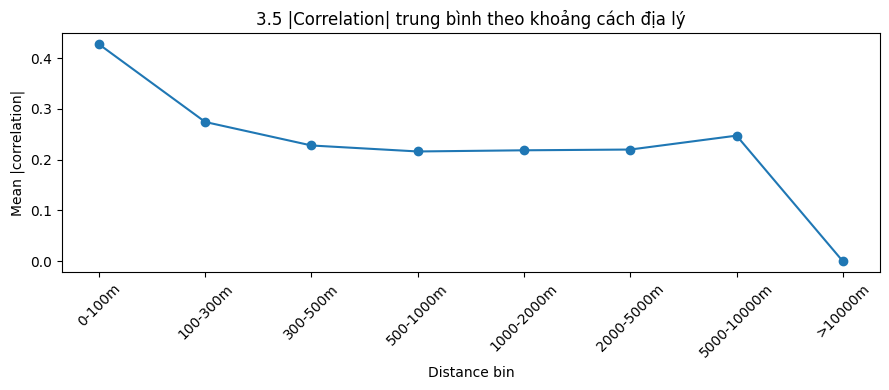

In [23]:

plt.figure(figsize=(9, 4))
plt.plot(geo_corr["distance_bin"], geo_corr["mean_abs_corr"], marker="o")
plt.title("3.5 |Correlation| trung bình theo khoảng cách địa lý")
plt.xlabel("Distance bin")
plt.ylabel("Mean |correlation|")
plt.xticks(rotation=45)
savefig("3_5_abs_corr_by_geo_distance.png")


## 3.6. Phân tích tương quan theo topology mạng đường OSM

Ta tạo graph cấp mô hình:

- Node = matched OSM directed edge.
- Hai node có cạnh topology nếu hai OSM edges chia sẻ một OSM endpoint.


Topology graph nodes: 3697
Topology graph edges: 11730
Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_6_topology_degree_distribution.png


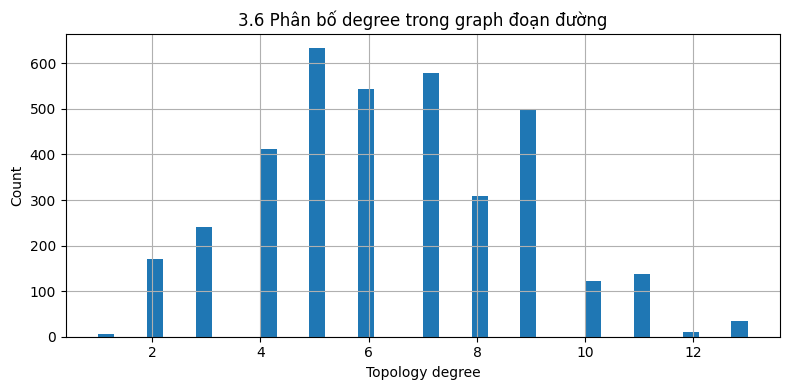

,model_node_id,topology_degree,valid_ratio
count,3697.0000,3697.000000,3697.0
mean,1848.0000,6.345686,1.0
std,1067.3763,2.363378,0.0
min,0.0000,1.000000,1.0
25%,924.0000,5.000000,1.0
50%,1848.0000,6.000000,1.0
75%,2772.0000,8.000000,1.0
max,3696.0000,13.000000,1.0


In [24]:

if nx is None:
    raise ImportError("Cần cài networkx để chạy phần topology.")

def build_line_graph_from_osm_edges(meta: pd.DataFrame) -> nx.Graph:
    G = nx.Graph()
    for _, row in meta.iterrows():
        G.add_node(int(row["model_node_id"]))

    endpoint_to_model_nodes = {}
    for _, row in meta.iterrows():
        node = int(row["model_node_id"])
        for endpoint in [int(row["osm_u_id"]), int(row["osm_v_id"])]:
            endpoint_to_model_nodes.setdefault(endpoint, []).append(node)

    for endpoint, nodes in endpoint_to_model_nodes.items():
        nodes = list(set(nodes))
        for a_idx in range(len(nodes)):
            for b_idx in range(a_idx + 1, len(nodes)):
                G.add_edge(nodes[a_idx], nodes[b_idx])
    return G

model_topology_graph = build_line_graph_from_osm_edges(edge_meta)
print("Topology graph nodes:", model_topology_graph.number_of_nodes())
print("Topology graph edges:", model_topology_graph.number_of_edges())

deg_series = pd.Series(dict(model_topology_graph.degree()), name="topology_degree")
topology_node_stats = pd.DataFrame({
    "model_node_id": deg_series.index.astype(int),
    "topology_degree": deg_series.values,
})
topology_node_stats = topology_node_stats.merge(node_stats[["model_node_id", "valid_ratio"]], on="model_node_id", how="left")
topology_node_stats.to_csv(TABLES_DIR / "3_6_topology_node_stats.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 4))
topology_node_stats["topology_degree"].hist(bins=40)
plt.title("3.6 Phân bố degree trong graph đoạn đường")
plt.xlabel("Topology degree")
plt.ylabel("Count")
savefig("3_6_topology_degree_distribution.png")

topology_node_stats.describe()


In [25]:

selected_set = set(selected_nodes.tolist())
node_to_pos = {int(node): i for i, node in enumerate(selected_nodes)}

neighbor_corr = []
for u, v in model_topology_graph.edges():
    if u in node_to_pos and v in node_to_pos:
        neighbor_corr.append(R[node_to_pos[u], node_to_pos[v]])
neighbor_corr = np.array(neighbor_corr, dtype=np.float32)

non_neighbor_corr = []
attempts = 0
target_non = min(len(neighbor_corr), 500_000)
while len(non_neighbor_corr) < target_non and attempts < 2_000_000:
    a, b = np.random.choice(selected_nodes, size=2, replace=False)
    if not model_topology_graph.has_edge(int(a), int(b)):
        non_neighbor_corr.append(R[node_to_pos[int(a)], node_to_pos[int(b)]])
    attempts += 1
non_neighbor_corr = np.array(non_neighbor_corr, dtype=np.float32)

neighbor_compare = pd.DataFrame({
    "group": ["topology_neighbor", "non_neighbor_sample"],
    "n_pairs": [len(neighbor_corr), len(non_neighbor_corr)],
    "mean_corr": [float(np.mean(neighbor_corr)), float(np.mean(non_neighbor_corr))],
    "mean_abs_corr": [float(np.mean(np.abs(neighbor_corr))), float(np.mean(np.abs(non_neighbor_corr)))],
    "q95_abs_corr": [float(np.quantile(np.abs(neighbor_corr), 0.95)), float(np.quantile(np.abs(non_neighbor_corr), 0.95))],
})
neighbor_compare.to_csv(TABLES_DIR / "3_6_neighbor_vs_non_neighbor_corr.csv", index=False, encoding="utf-8-sig")
neighbor_compare


,group,n_pairs,mean_corr,mean_abs_corr,q95_abs_corr
0,topology_neighbor,11730,0.494706,0.513749,0.982491
1,non_neighbor_sample,11730,0.126458,0.219680,0.627414


In [26]:

sources = np.random.choice(selected_nodes, size=min(MAX_HOP_SOURCES, len(selected_nodes)), replace=False)
hop_records = []

for src in sources:
    src = int(src)
    if src not in model_topology_graph or src not in node_to_pos:
        continue
    lengths = nx.single_source_shortest_path_length(model_topology_graph, src, cutoff=6)
    i = node_to_pos[src]
    for dst, hop in lengths.items():
        if dst == src or dst not in node_to_pos:
            continue
        j = node_to_pos[dst]
        hop_records.append({
            "source": src,
            "target": int(dst),
            "hop": int(hop),
            "corr": float(R[i, j]),
            "abs_corr": float(abs(R[i, j])),
        })

hop_df = pd.DataFrame(hop_records)
hop_summary = (
    hop_df
    .groupby("hop", as_index=False)
    .agg(
        n_pairs=("abs_corr", "size"),
        mean_corr=("corr", "mean"),
        mean_abs_corr=("abs_corr", "mean"),
        q95_abs_corr=("abs_corr", lambda x: np.quantile(x, 0.95)),
    )
)
hop_df.to_csv(TABLES_DIR / "3_6_hop_distance_pair_samples.csv", index=False, encoding="utf-8-sig")
hop_summary.to_csv(TABLES_DIR / "3_6_corr_by_hop_distance.csv", index=False, encoding="utf-8-sig")
hop_summary


,hop,n_pairs,mean_corr,mean_abs_corr,q95_abs_corr
0,1,2293,0.486407,0.505082,0.979285
1,2,3949,0.320069,0.356102,0.860010
2,3,6023,0.255543,0.304191,0.781967
3,4,8249,0.222077,0.276558,0.736485
4,5,10692,0.199540,0.262715,0.706841
5,6,13459,0.180603,0.251552,0.686350


Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_6_abs_corr_by_hop_distance.png


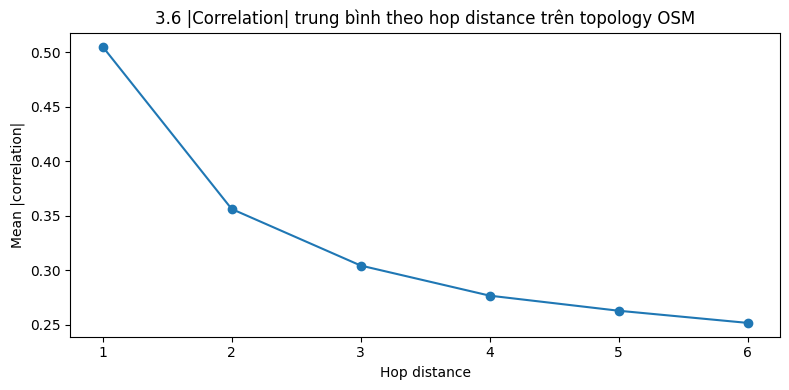

In [27]:

plt.figure(figsize=(8, 4))
plt.plot(hop_summary["hop"], hop_summary["mean_abs_corr"], marker="o")
plt.title("3.6 |Correlation| trung bình theo hop distance trên topology OSM")
plt.xlabel("Hop distance")
plt.ylabel("Mean |correlation|")
savefig("3_6_abs_corr_by_hop_distance.png")


## 3.7. Phân tích cụm/cộng đồng tương quan

Ta xây graph tương quan:

- Node = matched OSM edge.
- Edge = nếu correlation cao.
- Với mỗi node, giữ `top-k` node có tương quan dương lớn nhất và vượt ngưỡng.


In [28]:

def build_correlation_graph(R: np.ndarray, selected_nodes: np.ndarray, top_k: int, threshold: float) -> nx.Graph:
    G = nx.Graph()
    for node in selected_nodes:
        G.add_node(int(node))

    n = R.shape[0]
    for i in range(n):
        row = R[i].copy()
        row[i] = -np.inf
        k = min(top_k, n - 1)
        cand = np.argpartition(row, -k)[-k:]
        for j in cand:
            w = float(R[i, j])
            if w >= threshold:
                G.add_edge(int(selected_nodes[i]), int(selected_nodes[j]), weight=w)
    return G

corr_graph = build_correlation_graph(R, selected_nodes, TOP_K_CORR_GRAPH, CORR_GRAPH_THRESHOLD)

print("Correlation graph nodes:", corr_graph.number_of_nodes())
print("Correlation graph edges:", corr_graph.number_of_edges())
print("Connected components:", nx.number_connected_components(corr_graph))

if corr_graph.number_of_edges() == 0:
    print("Không có cạnh tương quan nào. Hãy giảm CORR_GRAPH_THRESHOLD.")


Correlation graph nodes: 3697
Correlation graph edges: 19556
Connected components: 289


In [29]:

if corr_graph.number_of_edges() > 0:
    communities = list(nx.algorithms.community.greedy_modularity_communities(corr_graph, weight="weight"))
else:
    communities = [{n} for n in corr_graph.nodes()]

community_rows = []
node_comm_rows = []

for cid, comm in enumerate(communities):
    nodes = sorted([int(x) for x in comm])
    sub_meta = edge_meta[edge_meta["model_node_id"].isin(nodes)]
    street_terms = (
        sub_meta["street_names"]
        .dropna()
        .astype(str)
        .str.split("|")
        .explode()
        .value_counts()
        .head(8)
        .index
        .tolist()
    )
    community_rows.append({
        "community_id": cid,
        "size": len(nodes),
        "mean_mid_lat": sub_meta["mid_lat"].mean(),
        "mean_mid_lon": sub_meta["mid_lon"].mean(),
        "top_street_names": "|".join(street_terms),
    })
    for n0 in nodes:
        node_comm_rows.append({"model_node_id": n0, "community_id": cid})

community_df = pd.DataFrame(community_rows).sort_values("size", ascending=False)
node_community_df = pd.DataFrame(node_comm_rows)

community_df.to_csv(TABLES_DIR / "3_7_correlation_communities_summary.csv", index=False, encoding="utf-8-sig")
node_community_df.to_csv(TABLES_DIR / "3_7_node_community_mapping.csv", index=False, encoding="utf-8-sig")

community_df.head(20)


,community_id,size,mean_mid_lat,mean_mid_lon,top_street_names
0,0,796,10.777782,106.691141,Đường Nguyễn Thị Minh Khai|Đường Cách Mạng Thá...
1,1,424,10.792004,106.700269,Đường Xô Viết Nghệ Tĩnh|Đường Điện Biên Phủ|Đư...
2,2,292,10.771509,106.695949,Đường Trần Hưng Đạo|Đường Nguyễn Trãi|Đường Hà...
3,3,181,10.791319,106.684693,Đường Hoàng Sa|Đường Nam Kỳ Khởi Nghĩa|Hẻm 60 ...
4,4,130,10.803109,106.692757,Đường Phan Đăng Lưu|Đường Bạch Đằng|Đường Lê Q...
5,5,116,10.798652,106.677757,Đường Hoàng Văn Thụ|Đường Nguyễn Văn Trỗi|Đườn...
6,6,99,10.787245,106.708526,Đường Nguyễn Hữu Cảnh|Đường Nguyễn Bỉnh Khiêm|...
7,7,94,10.772594,106.709032,Đường Hầm sông Sài Gòn|Đường Nguyễn Tất Thành|...
8,8,81,10.764661,106.691756,Đường Trần Hưng Đạo|Đường Bùi Viện|Đường Đỗ Qu...
9,9,67,10.763648,106.700555,Đường Bến Vân Đồn|Đường Calmette|Đường Đoàn Vă...


Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_7_community_size_distribution.png


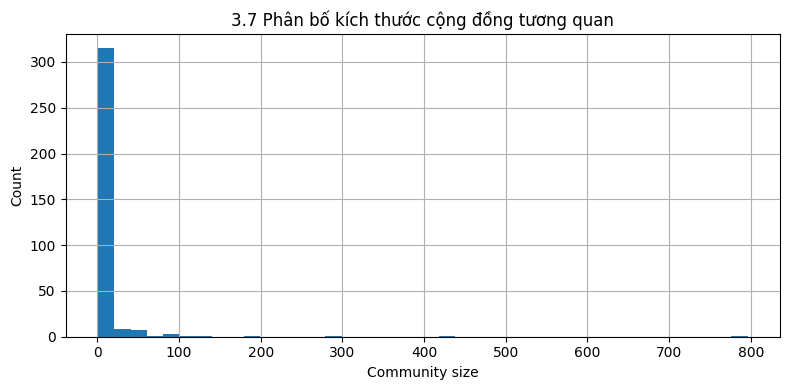

Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_7_top_communities_geo_scatter.png


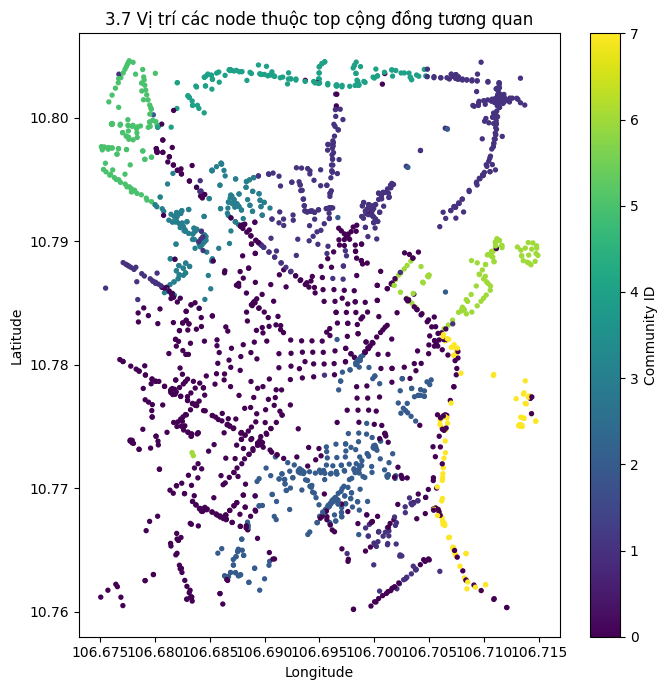

In [30]:

plt.figure(figsize=(8, 4))
community_df["size"].hist(bins=40)
plt.title("3.7 Phân bố kích thước cộng đồng tương quan")
plt.xlabel("Community size")
plt.ylabel("Count")
savefig("3_7_community_size_distribution.png")

top_cids = community_df.head(8)["community_id"].tolist()
plot_meta = selected_meta[["model_node_id", "mid_lat", "mid_lon", "street_names"]].merge(
    node_community_df,
    on="model_node_id",
    how="left",
)
plot_meta_top = plot_meta[plot_meta["community_id"].isin(top_cids)].copy()

plt.figure(figsize=(7, 7))
plt.scatter(plot_meta_top["mid_lon"], plot_meta_top["mid_lat"], s=8, c=plot_meta_top["community_id"])
plt.title("3.7 Vị trí các node thuộc top cộng đồng tương quan")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Community ID")
savefig("3_7_top_communities_geo_scatter.png")


## 3.8. Phân tích quan hệ tương quan có độ trễ

Phân tích:

\[
Corr(X_i(t), X_j(t+k))
\]

với \(k = 1, 2, \dots, 9\).


In [31]:

node_var = pd.Series(np.nanvar(X, axis=0), index=selected_nodes, name="variance")
lag_node_rank = (
    pd.DataFrame({"model_node_id": selected_nodes})
    .merge(node_stats[["model_node_id", "valid_ratio"]], on="model_node_id", how="left")
    .merge(node_var.reset_index().rename(columns={"index": "model_node_id"}), on="model_node_id", how="left")
    .sort_values(["valid_ratio", "variance"], ascending=[False, False])
)
lag_nodes = lag_node_rank["model_node_id"].head(min(MAX_LAG_NODES, len(selected_nodes))).to_numpy(dtype=np.int64)
lag_positions = np.array([node_to_pos[int(n)] for n in lag_nodes], dtype=np.int64)
X_lag = X[:, lag_positions]

print("Lag analysis nodes:", len(lag_nodes))
print("X_lag shape:", X_lag.shape)


Lag analysis nodes: 1000
X_lag shape: (720, 1000)


In [32]:

max_lag = 9
lag_summaries = []
top_lag_rows = []

for lag in range(1, max_lag + 1):
    A = X_lag[:-lag]
    B = X_lag[lag:]

    ZA = standardize_matrix(A)
    ZB = standardize_matrix(B)

    C = (ZA.T @ ZB) / max(1, ZA.shape[0] - 1)
    C = C.astype(np.float32)
    np.fill_diagonal(C, np.nan)

    vals = C[np.isfinite(C)]
    abs_vals = np.abs(vals)

    lag_summaries.append({
        "lag": lag,
        "n_values": len(vals),
        "mean_corr": float(np.mean(vals)),
        "mean_abs_corr": float(np.mean(abs_vals)),
        "q95_abs_corr": float(np.quantile(abs_vals, 0.95)),
        "q99_abs_corr": float(np.quantile(abs_vals, 0.99)),
        "count_abs_corr_gt_0_5": int(np.sum(abs_vals > 0.5)),
        "count_abs_corr_gt_0_7": int(np.sum(abs_vals > 0.7)),
    })

    flat = np.nan_to_num(C, nan=-np.inf).ravel()
    top_k = min(50, len(flat))
    idxs = np.argpartition(flat, -top_k)[-top_k:]
    for idx in idxs:
        i = idx // C.shape[1]
        j = idx % C.shape[1]
        if i == j:
            continue
        top_lag_rows.append({
            "lag": lag,
            "source_node_i_at_t": int(lag_nodes[i]),
            "target_node_j_at_t_plus_lag": int(lag_nodes[j]),
            "lag_corr": float(C[i, j]),
        })

lag_summary_df = pd.DataFrame(lag_summaries)
top_lag_pairs_df = pd.DataFrame(top_lag_rows).sort_values(["lag", "lag_corr"], ascending=[True, False])

lag_summary_df.to_csv(TABLES_DIR / "3_8_lagged_correlation_summary.csv", index=False, encoding="utf-8-sig")
top_lag_pairs_df.to_csv(TABLES_DIR / "3_8_top_lagged_pairs.csv", index=False, encoding="utf-8-sig")

lag_summary_df


,lag,n_values,mean_corr,mean_abs_corr,q95_abs_corr,q99_abs_corr,count_abs_corr_gt_0_5,count_abs_corr_gt_0_7
0,1,999000,0.011013,0.098194,0.308326,0.585794,20281,2114
1,2,999000,0.009764,0.081604,0.259667,0.518716,11927,628
2,3,999000,0.008716,0.068773,0.218268,0.457704,6390,130
3,4,999000,0.007552,0.061059,0.188454,0.405736,3128,45
4,5,999000,0.006966,0.056991,0.170692,0.361232,1674,3
5,6,999000,0.006112,0.054869,0.162986,0.329015,991,0
6,7,999000,0.004966,0.052769,0.155308,0.295659,559,0
7,8,999000,0.003438,0.050103,0.144983,0.264171,363,0
8,9,999000,0.002726,0.048768,0.139693,0.245890,180,0


Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_8_mean_abs_lagged_corr_by_lag.png


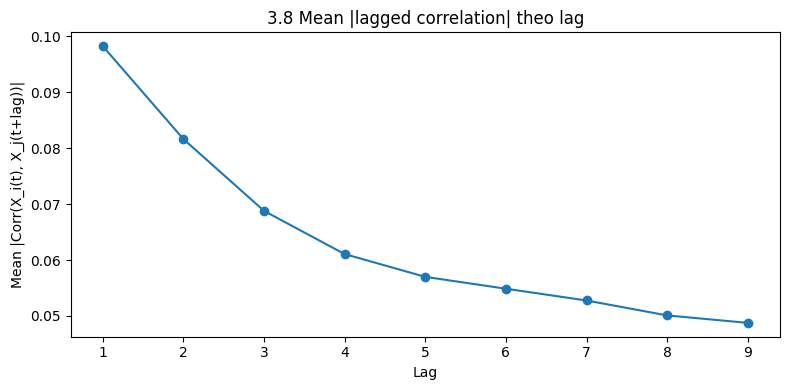

Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_8_strong_lagged_relations_by_lag.png


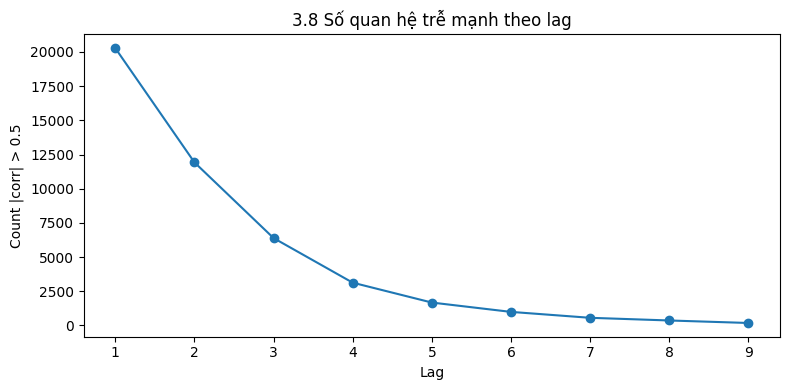

,lag,source_node_i_at_t,target_node_j_at_t_plus_lag,lag_corr
49,1,1571,1570,0.925592
48,1,1570,1571,0.924698
47,1,1795,1571,0.922417
46,1,1795,1570,0.920193
45,1,1571,1795,0.912465
44,1,1570,1795,0.908663
43,1,622,2457,0.878669
0,1,2913,2911,0.876331
1,1,2919,2915,0.876331
2,1,2919,2916,0.876331


In [33]:

plt.figure(figsize=(8, 4))
plt.plot(lag_summary_df["lag"], lag_summary_df["mean_abs_corr"], marker="o")
plt.title("3.8 Mean |lagged correlation| theo lag")
plt.xlabel("Lag")
plt.ylabel("Mean |Corr(X_i(t), X_j(t+lag))|")
savefig("3_8_mean_abs_lagged_corr_by_lag.png")

plt.figure(figsize=(8, 4))
plt.plot(lag_summary_df["lag"], lag_summary_df["count_abs_corr_gt_0_5"], marker="o")
plt.title("3.8 Số quan hệ trễ mạnh theo lag")
plt.xlabel("Lag")
plt.ylabel("Count |corr| > 0.5")
savefig("3_8_strong_lagged_relations_by_lag.png")

top_lag_pairs_df.head(20)


## 3.9. Phân tích độ ổn định của tương quan theo thời gian

Nếu ma trận tương quan thay đổi chậm, **Persistence/EWMA** có thể rất mạnh. Nếu biến động nhiều, các mô hình động có thêm cơ hội cải thiện.


In [34]:

stab_node_rank = lag_node_rank.head(min(MAX_STABILITY_NODES, len(selected_nodes)))
stab_nodes = stab_node_rank["model_node_id"].to_numpy(dtype=np.int64)
stab_positions = np.array([node_to_pos[int(n)] for n in stab_nodes], dtype=np.int64)
X_stab = X[:, stab_positions]

print("Stability nodes:", len(stab_nodes))
print("X_stab shape:", X_stab.shape)

stability_rows = []
prev_Rw = None

for start in range(0, X_stab.shape[0] - CORR_WINDOW + 1, STABILITY_STEP):
    end = start + CORR_WINDOW
    W = X_stab[start:end]
    Rw = np.corrcoef(W, rowvar=False).astype(np.float32)
    Rw = np.nan_to_num(Rw, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(Rw, 1.0)

    if prev_Rw is not None:
        diff = Rw - prev_Rw
        frob = float(np.linalg.norm(diff) / math.sqrt(diff.size))

        iu = np.triu_indices(Rw.shape[0], k=1)
        a = prev_Rw[iu]
        b = Rw[iu]
        sim = np.nan if np.std(a) < 1e-8 or np.std(b) < 1e-8 else float(np.corrcoef(a, b)[0, 1])

        stability_rows.append({
            "window_start": start,
            "window_end": end,
            "prev_window_start": start - STABILITY_STEP,
            "frob_diff_norm": frob,
            "upper_triangle_similarity": sim,
            "mean_abs_corr": float(np.mean(np.abs(Rw[iu]))),
        })

    prev_Rw = Rw

stability_df = pd.DataFrame(stability_rows)
stability_df.to_csv(TABLES_DIR / "3_9_correlation_stability_over_time.csv", index=False, encoding="utf-8-sig")
stability_df.head()


Stability nodes: 800
X_stab shape: (720, 800)


,window_start,window_end,prev_window_start,frob_diff_norm,upper_triangle_similarity,mean_abs_corr
0,4,14,0,0.414038,0.395244,0.286337
1,8,18,4,0.361346,0.458767,0.278396
2,12,22,8,0.353546,0.467144,0.277823
3,16,26,12,0.441829,0.274584,0.317256
4,20,30,16,0.290972,0.702774,0.290012


Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_9_rolling_corr_frobenius_diff.png


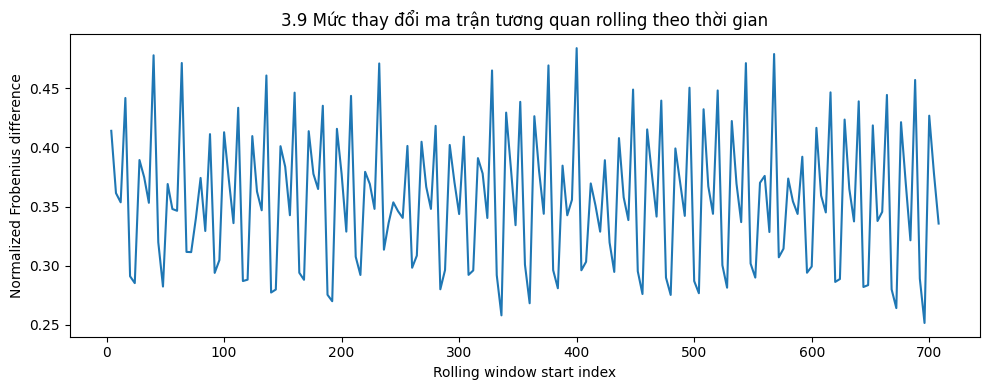

Saved plot: C:\AI\Thesis\UTraffic-ML\ml_core\src\data_processing\outputs\branchA\analysis_report\plots\3_9_rolling_corr_similarity.png


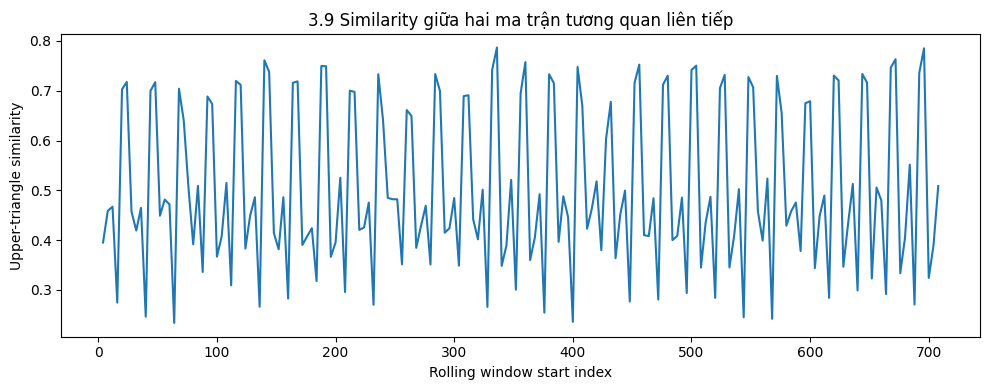

In [35]:

plt.figure(figsize=(10, 4))
plt.plot(stability_df["window_start"], stability_df["frob_diff_norm"])
plt.title("3.9 Mức thay đổi ma trận tương quan rolling theo thời gian")
plt.xlabel("Rolling window start index")
plt.ylabel("Normalized Frobenius difference")
savefig("3_9_rolling_corr_frobenius_diff.png")

plt.figure(figsize=(10, 4))
plt.plot(stability_df["window_start"], stability_df["upper_triangle_similarity"])
plt.title("3.9 Similarity giữa hai ma trận tương quan liên tiếp")
plt.xlabel("Rolling window start index")
plt.ylabel("Upper-triangle similarity")
savefig("3_9_rolling_corr_similarity.png")


## 3.10. Nhận xét và hàm ý cho bài toán dự đoán

In [36]:

remarks = []

coverage = summary.get("match", {}).get("coverage_tomtom_segments", None)
num_model_nodes = summary.get("match", {}).get("model_nodes_for_branchA_B", None)
if coverage is not None:
    remarks.append(f"Tỷ lệ match TomTom→OSM đạt {coverage:.2%}, cho thấy không gian OSM edge có thể đại diện tốt cho dữ liệu TomTom.")
if num_model_nodes is not None:
    remarks.append(f"Sau map-matching, số node mô hình là {num_model_nodes:,}, trong đó mỗi node đại diện cho một matched OSM directed edge.")

mean_abs_corr = corr_dist_summary.loc[corr_dist_summary["metric"] == "mean_abs_corr", "value"].iloc[0]
ratio_strong = corr_dist_summary.loc[corr_dist_summary["metric"] == "ratio_abs_corr_gt_0_5", "value"].iloc[0]
remarks.append(f"Mean |correlation| toàn mạng khoảng {mean_abs_corr:.4f}; tỷ lệ cặp node có |corr| > 0.5 khoảng {ratio_strong:.2%}.")

if not geo_corr.empty:
    first_bin_abs = geo_corr["mean_abs_corr"].iloc[0]
    last_valid_abs = geo_corr.loc[geo_corr["n_pairs_sampled"] > 0, "mean_abs_corr"].iloc[-1]
    if first_bin_abs > last_valid_abs:
        remarks.append("Các cặp đoạn đường gần nhau về địa lý có xu hướng tương quan mạnh hơn các cặp ở xa.")
    else:
        remarks.append("Tương quan không giảm rõ ràng theo khoảng cách địa lý; cần xem xét thêm topology hoặc quan hệ theo trục đường.")

if not neighbor_compare.empty:
    neigh_abs = neighbor_compare.loc[neighbor_compare["group"] == "topology_neighbor", "mean_abs_corr"].iloc[0]
    non_abs = neighbor_compare.loc[neighbor_compare["group"] == "non_neighbor_sample", "mean_abs_corr"].iloc[0]
    if neigh_abs > non_abs:
        remarks.append(f"Các đoạn đường kề nhau trên topology OSM có mean |corr|={neigh_abs:.4f}, cao hơn non-neighbor sample={non_abs:.4f}.")
    else:
        remarks.append("Tương quan topology-neighbor không cao hơn rõ rệt non-neighbor sample; cần xét quan hệ vùng/cụm thay vì chỉ xét kề trực tiếp.")

best_lag = int(lag_summary_df.sort_values("mean_abs_corr", ascending=False)["lag"].iloc[0])
remarks.append(f"Lag có mean |lagged correlation| cao nhất trong phạm vi 1–9 là lag={best_lag}; đây là gợi ý quan trọng cho Branch B.")

if not stability_df.empty:
    mean_sim = stability_df["upper_triangle_similarity"].mean()
    mean_diff = stability_df["frob_diff_norm"].mean()
    remarks.append(f"Độ ổn định rolling correlation: similarity trung bình={mean_sim:.4f}, normalized Frobenius diff trung bình={mean_diff:.4f}.")
    if mean_sim > 0.8:
        remarks.append("Ma trận tương quan tương đối ổn định ngắn hạn, vì vậy Persistence/EWMA có thể là baseline rất mạnh.")
    else:
        remarks.append("Ma trận tương quan thay đổi đáng kể theo thời gian, nên các mô hình động có thể có lợi thế.")

remarks_text = "\n".join([f"{i+1}. {r}" for i, r in enumerate(remarks)])
print(remarks_text)

with open(ANALYSIS_DIR / "3_10_remarks_and_implications.txt", "w", encoding="utf-8") as f:
    f.write(remarks_text)

final_summary = {
    "basic_summary": basic_summary,
    "corr_summary": corr_summary,
    "remarks": remarks,
    "output_dirs": {
        "analysis_dir": str(ANALYSIS_DIR),
        "plots_dir": str(PLOTS_DIR),
        "tables_dir": str(TABLES_DIR),
        "matrices_dir": str(MATRICES_DIR),
    }
}
save_json(final_summary, ANALYSIS_DIR / "analysis_final_summary.json")


1. Tỷ lệ match TomTom→OSM đạt 99.73%, cho thấy không gian OSM edge có thể đại diện tốt cho dữ liệu TomTom.
2. Sau map-matching, số node mô hình là 3,697, trong đó mỗi node đại diện cho một matched OSM directed edge.
3. Mean |correlation| toàn mạng khoảng 0.2461; tỷ lệ cặp node có |corr| > 0.5 khoảng 16.06%.
4. Các cặp đoạn đường gần nhau về địa lý có xu hướng tương quan mạnh hơn các cặp ở xa.
5. Các đoạn đường kề nhau trên topology OSM có mean |corr|=0.5137, cao hơn non-neighbor sample=0.2197.
6. Lag có mean |lagged correlation| cao nhất trong phạm vi 1–9 là lag=1; đây là gợi ý quan trọng cho Branch B.
7. Độ ổn định rolling correlation: similarity trung bình=0.5043, normalized Frobenius diff trung bình=0.3563.
8. Ma trận tương quan thay đổi đáng kể theo thời gian, nên các mô hình động có thể có lợi thế.


# Kết thúc notebook

Sau khi chạy toàn bộ notebook, kết quả sẽ được lưu tại:

```text
ml_core/src/data_processing/outputs/branchA/analysis_report/
```

Các output chính:

```text
analysis_report/
  plots/      # hình ảnh phân tích
  tables/     # bảng CSV
  matrices/   # X và R dạng .npy
```
